# MNIST: Building and Training a CNN

**Prepared by Fonyuy Gita — SEED AI Bootcamp, Deep Learning Module (CNN track)**

Same structure as `02_cifar10_cnn_training.ipynb`, but with a smaller,
simpler network, MNIST doesn't need the depth or augmentation that
CIFAR-10 required. This is intentional: comparing the two side by side
shows how architecture choices should match the difficulty of the data,
not just be copy-pasted between problems.

Run `01_mnist_data_preparation.ipynb` first if you haven't already.

**What this notebook covers:**
1. Load the prepared data
2. Build a small CNN
3. Train it
4. Visualize training
5. Evaluate on the test set
6. Save the model and run inference on a sample digit


## Step 1: Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import confusion_matrix, classification_report

tf.random.set_seed(42)
np.random.seed(42)
print("done loading libraries")


done loading libraries


## Step 2: Load the prepared data

In [3]:
X_train = np.load('mnist_X_train.npy')
y_train = np.load('mnist_y_train.npy')
X_val = np.load('mnist_X_val.npy')
y_val = np.load('mnist_y_val.npy')
X_test = np.load('mnist_X_test.npy')
y_test = np.load('mnist_y_test.npy')

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")


Train: (54000, 28, 28, 1)
Val:   (6000, 28, 28, 1)
Test:  (10000, 28, 28, 1)


## Step 3: Build the CNN

MNIST digits are simple: one shape, centered, on a plain black
background, no texture, no lighting variation, no background clutter.
That means the network needs far less capacity than CIFAR-10's CNN,
fewer filters, fewer blocks, no augmentation required to get excellent
results.

```mermaid
flowchart TD
    A["Input 28x28x1"] --> B["Conv2D (32 filters) + Pool, 28x28x1 -> 14x14x32"]
    B --> C["Conv2D (64 filters) + Pool, 14x14x32 -> 7x7x64"]
    C --> D["Flatten, 7x7x64 -> 3136"]
    D --> E["Dense 128 + Dropout"]
    E --> F["Dense 10, softmax, digit probabilities"]
```

Compare this to the CIFAR-10 diagram from the last notebook: **half as
many convolutional blocks, no data augmentation layer, no spatial
dropout.** This isn't a shortcut, it's a deliberate match between model
complexity and problem difficulty. Using the full CIFAR-10-sized network
here would train slower for no accuracy benefit, and an oversized network
on an easy problem is more prone to overfitting, the same lesson from
matching ANN size to dataset size in the heart disease project.


In [4]:
def build_mnist_cnn(num_classes=10):
    inputs = keras.Input(shape=(28, 28, 1), name='image')

    # Block 1: 28x28x1 -> 14x14x32
    x = keras.layers.Conv2D(32, 3, padding='same')(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.MaxPooling2D(2)(x)

    # Block 2: 14x14x32 -> 7x7x64
    x = keras.layers.Conv2D(64, 3, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.MaxPooling2D(2)(x)

    # Classifier head: 7x7x64 -> 10
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(128, activation='relu')(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax', name='digit_probs')(x)

    return keras.Model(inputs, outputs, name='MNISTNet')


model = build_mnist_cnn()
model.summary()


Model: "MNISTNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                   │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ digit_probs (Dense)                  │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

In [6]:
dummy = tf.random.normal([4, 28, 28, 1])
output = model(dummy, training=False)
print(f"Output shape: {output.shape}")
print(f"Total parameters: {model.count_params():,}")

# Compare to the CIFAR-10 model's parameter count from the previous notebook,
# this one should be noticeably smaller, matching the simpler problem.
dummy

Output shape: (4, 10)
Total parameters: 422,026


<tf.Tensor: shape=(4, 28, 28, 1), dtype=float32, numpy=
array([[[[ 0.08422458],
         [-0.86090374],
         [ 0.37812304],
         ...,
         [-0.3376326 ],
         [-0.8959325 ],
         [ 0.42754072]],

        [[-0.38105518],
         [ 0.47006992],
         [ 0.03541378],
         ...,
         [-0.5973676 ],
         [-1.6903349 ],
         [ 0.74853486]],

        [[-0.412243  ],
         [ 0.819555  ],
         [-1.4472327 ],
         ...,
         [ 1.2384809 ],
         [-0.01177637],
         [-0.41682106]],

        ...,

        [[-1.1611848 ],
         [-0.3034008 ],
         [-1.0571958 ],
         ...,
         [-0.28512245],
         [-0.4578255 ],
         [ 0.0733528 ]],

        [[ 0.4893095 ],
         [-0.5651258 ],
         [-1.1470953 ],
         ...,
         [ 0.7474812 ],
         [ 0.6803373 ],
         [-0.8658315 ]],

        [[ 0.926413  ],
         [-2.2535892 ],
         [ 0.7854608 ],
         ...,
         [-0.6541982 ],
         [ 0.8386107

## Step 4: Compile the model

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## Step 5: Train the model

Expect this to train noticeably faster per epoch than CIFAR-10, smaller
images, fewer channels, a smaller network, and no augmentation overhead.

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, mode='max', verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.5, patience=3,
        mode='max', min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(
        'best_mnist_model.keras', monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=0),
]

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

print(f"\nEpochs run: {len(history.history['loss'])}")
print(f"Best val accuracy: {max(history.history['val_accuracy']):.4f}")


Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 75s 163ms/step - accuracy: 0.9135 - loss: 0.2894 - val_accuracy: 0.9377 - val_loss: 0.2336 - learning_rate: 0.0010
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 59s 140ms/step - accuracy: 0.9679 - loss: 0.1071 - val_accuracy: 0.9765 - val_loss: 0.0789 - learning_rate: 0.0010
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 58s 137ms/step - accuracy: 0.9758 - loss: 0.0836 - val_accuracy: 0.9867 - val_loss: 0.0440 - learning_rate: 0.0010
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 76s 124ms/step - accuracy: 0.9798 - loss: 0.0669 - val_accuracy: 0.9878 - val_loss: 0.0467 - learning_rate: 0.0010
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 51s 121ms/step - accuracy: 0.9818 - loss: 0.0596 - val_accuracy: 0.9900 - val_loss: 0.0373 - learning_rate: 0.0010
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 50s 119ms/step - accuracy: 0.9841 - loss: 0.0514 - val_accuracy: 0.9893 - val_loss: 0.0380 - learning_rate: 0.0010
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 63s 149ms/step - accuracy: 0.9

## Step 6: Visualize training

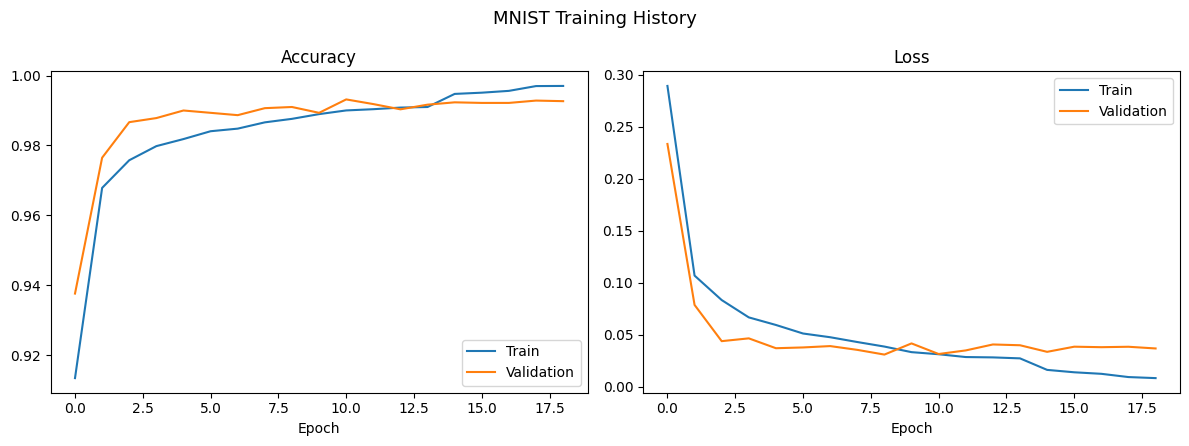

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('MNIST Training History', fontsize=13)
plt.tight_layout()
plt.savefig('mnist_training_history.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 7: Evaluate on the test set

In [10]:
model.load_weights('best_mnist_model.keras')

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

y_prob = model.predict(X_test, verbose=0)
y_pred = y_prob.argmax(axis=1)


Test loss:     0.0295
Test accuracy: 0.9916


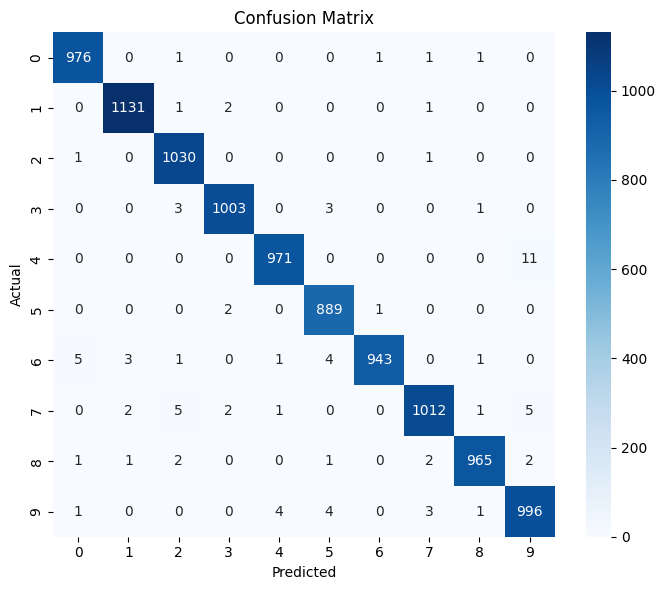

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      1.00      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('mnist_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred))


Look for which digit pairs get confused most, `4` and `9`, or `3` and
`5`, are common mix-ups, they genuinely share more shape similarity with
each other than with, say, `0` or `1`.

## Step 8: Save the model

In [12]:
model.save('mnist_cnn.keras')
print("Saved mnist_cnn.keras")


Saved mnist_cnn.keras


## Step 9: Run inference on a sample digit

Actual label: 1


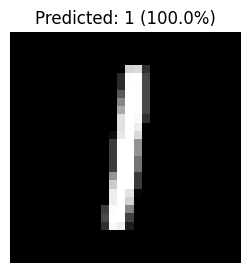

All class probabilities:
  0: 0.0%  
  1: 100.0%  #######################################
  2: 0.0%  
  3: 0.0%  
  4: 0.0%  
  5: 0.0%  
  6: 0.0%  
  7: 0.0%  
  8: 0.0%  
  9: 0.0%  


In [13]:
def predict_digit(image, model):
    """image: a single image array, shape (28, 28, 1), values in [0, 1]"""
    batch = image[np.newaxis, ...]
    probabilities = model.predict(batch, verbose=0)[0]
    predicted_digit = probabilities.argmax()

    plt.figure(figsize=(3, 3))
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"Predicted: {predicted_digit} ({probabilities[predicted_digit]:.1%})")
    plt.axis('off')
    plt.show()

    print("All class probabilities:")
    for digit, prob in enumerate(probabilities):
        bar = '#' * int(prob * 40)
        print(f"  {digit}: {prob:.1%}  {bar}")


sample_idx = np.random.randint(len(X_test))
print(f"Actual label: {y_test[sample_idx]}")
predict_digit(X_test[sample_idx], model)


### Done

MNIST and CIFAR-10 used the exact same overall workflow, load, normalize,
build, compile, train with callbacks, evaluate, save, but the network
itself was intentionally smaller and simpler here. That comparison is
the real lesson of pairing these two notebooks: a CNN's size and
complexity should be chosen to match the problem in front of it, not
copied wholesale from the last project.